In [ ]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('poster')
import pymc as pm
import pytensor.tensor as pt
import arviz as az

## A gaussian with correlations

We wish to sample a 2D Posterior which looks something like below. Here the x and y axes are parameters.

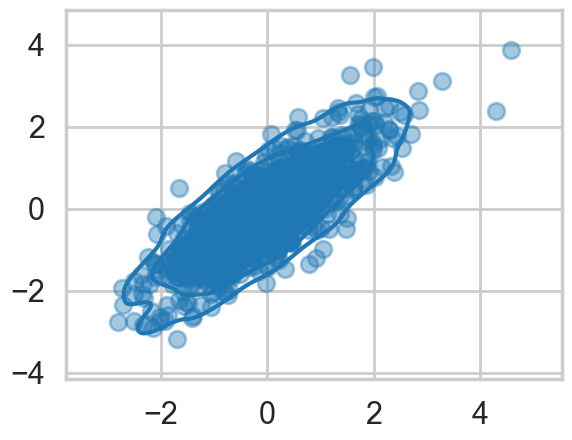

In [3]:
cov=np.array([[1,0.8],[0.8,1]])
data = np.random.multivariate_normal([0,0], cov, size=1000)
sns.kdeplot(x=data[:,0], y=data[:,1]);
plt.scatter(data[:,0], data[:,1], alpha=0.4)

To model a covariance, consider that in can be written thus:

![](assets/cov1.png)

which can then be written as:

![](assets/cov2.png)

Where $R$ is a correlation matrix (with 1's down its diagonal)

In [4]:
def pm_make_cov(sigpriors, corr_coeffs, ndim):
    sigma_matrix = pt.diag(sigpriors)
    n_elem = int(ndim * (ndim - 1) / 2)
    tri_index = np.zeros([ndim, ndim], dtype=int)
    tri_index[np.triu_indices(ndim, k=1)] = np.arange(n_elem)
    tri_index[np.triu_indices(ndim, k=1)[::-1]] = np.arange(n_elem)
    corr_matrix = corr_coeffs[tri_index]
    corr_matrix = pt.fill_diagonal(corr_matrix, 1)
    return pt.nlinalg.matrix_dot(sigma_matrix, corr_matrix, sigma_matrix)

### Matrixy indexing

In [5]:
tri_index = np.zeros([3, 3], dtype=int)
tri_index

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]])

In [6]:
tri_index[np.triu_indices(3, k=1)] = np.arange(3)
print(tri_index)
tri_index[np.triu_indices(3, k=1)[::-1]] = np.arange(3)

print(tri_index)



[[0 0 1]
 [0 0 2]
 [0 0 0]]
[[0 0 1]
 [0 0 2]
 [1 2 0]]


In [7]:
test=np.array([5,6,7])
test[tri_index]

array([[5, 5, 6],
       [5, 5, 7],
       [6, 7, 5]])

## The LKJ prior for sampling

Our correlation matrices need a prior. In the 2-D case they looklike

```
1 rho
rho 1
```

In a linear regression scenario, you can think of `rho` as a correlation between the intercept and the slope. Here there is just one parameter to create a prior for. Of-course in larger models, with more intercepts and slopes..think hierarchical models here...there is more than one `rho`.

The prior we use for this is the [LKJ prior](https://www.sciencedirect.com/science/article/pii/S0047259X09000876)

In [8]:
eta1 = pm.draw(pm.LKJCorr.dist(eta=1, n=2), draws=10000).flatten()
eta3 = pm.draw(pm.LKJCorr.dist(eta=3, n=2), draws=10000).flatten()
eta5 = pm.draw(pm.LKJCorr.dist(eta=5, n=2), draws=10000).flatten()
eta10 = pm.draw(pm.LKJCorr.dist(eta=10, n=2), draws=10000).flatten()

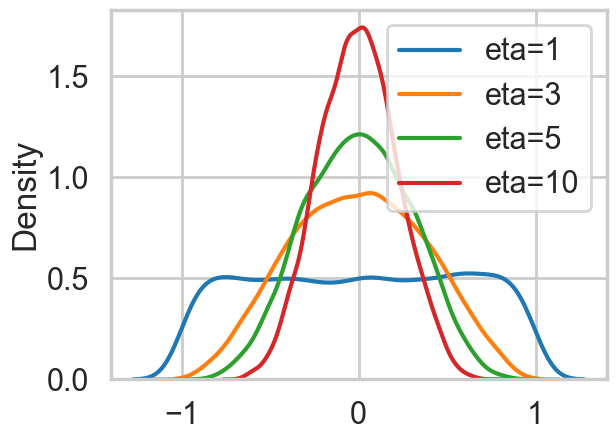

In [9]:
with sns.plotting_context('poster'):
    sns.kdeplot(eta1, label='eta=1')
    sns.kdeplot(eta3, label='eta=3')
    sns.kdeplot(eta5, label='eta=5')
    sns.kdeplot(eta10, label='eta=10')
    plt.legend();

Notice $\eta=1$ is almost uniform in correlation while higher values penalize extreme correlations.

Why use this prior? The standard prior for MVN covariances used to be the inverse wishart prior. Howerver that prior has much heavier tails and tends to put too much weight on extreme correlations.

In [10]:
sigs=np.array([1,1])

In [11]:
# Note: In modern pymc, LKJCorr requires a constant eta parameter.
with pm.Model() as modelmvg:
    ndim = 2
    corr_coeffs = pm.LKJCorr('corr_coeffs', eta=2, n=ndim)
    cov = pm_make_cov(sigs, corr_coeffs, ndim)
    mvg = pm.MvNormal('mvg', mu=[0,0], cov=cov, observed=data)

    nutstrace = pm.sample(10000, cores=1)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [corr_coeffs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 11 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


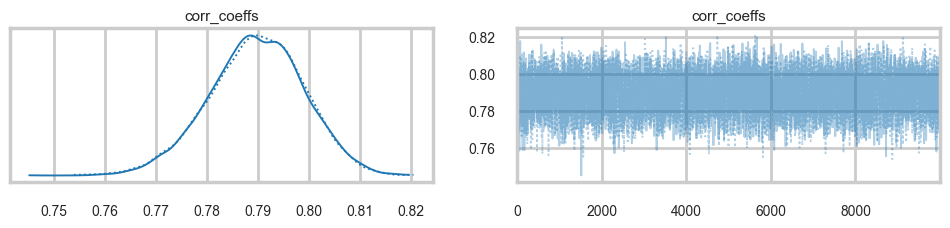

In [12]:
az.plot_trace(nutstrace);

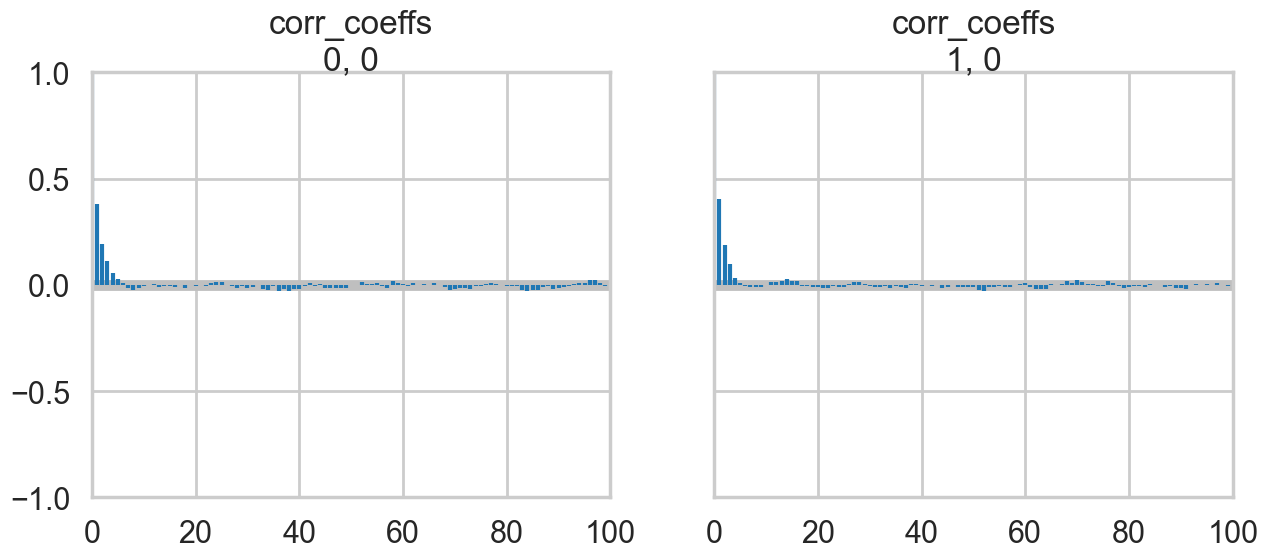

In [13]:
az.plot_autocorr(nutstrace);

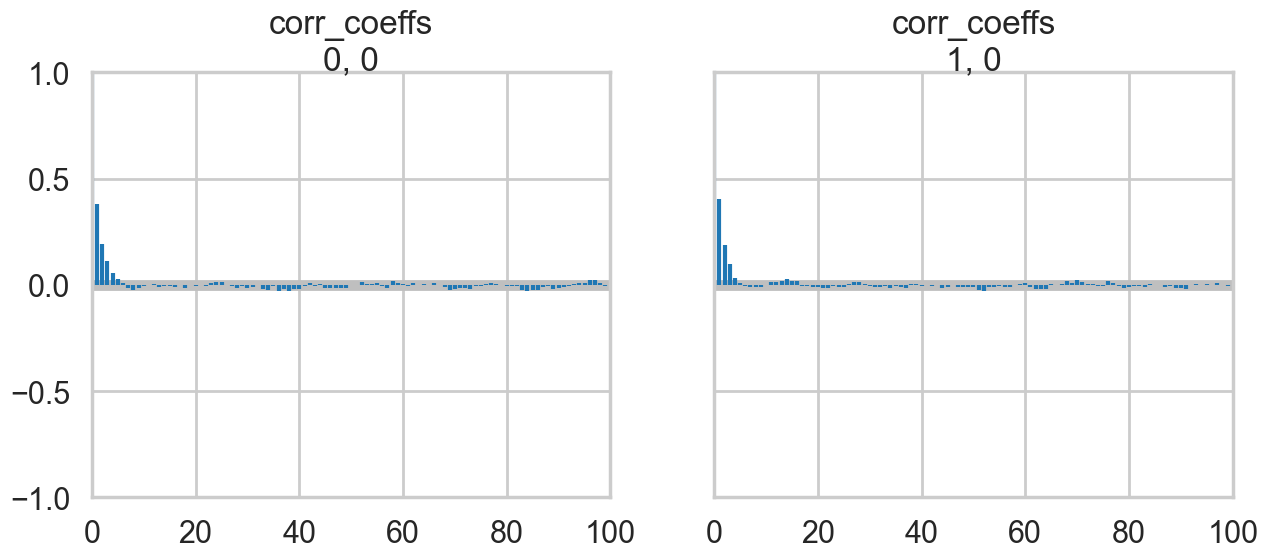

In [14]:
az.plot_autocorr(nutstrace);

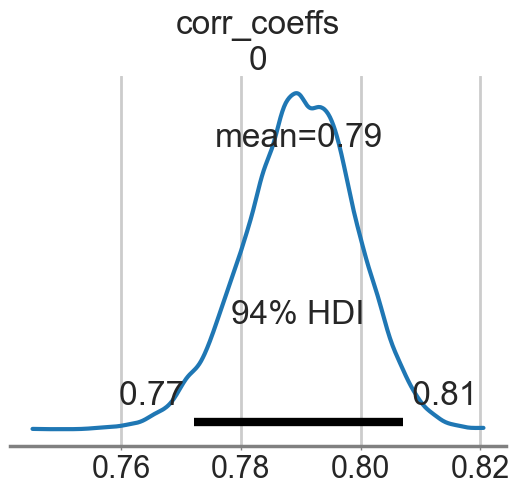

In [15]:
az.plot_posterior(nutstrace);

In [16]:
with pm.Model() as modelmvg2:
    ndim = 2
    sigs = pt.stack([pm.Lognormal('sigma_%d' % i, 0, 1) for i in [0, 1]])
    corr_coeffs = pm.LKJCorr('corr_coeffs', eta=2, n=ndim)
    cov = pm_make_cov(sigs, corr_coeffs, ndim)
    mvg = pm.MvNormal('mvg', mu=[0,0], cov=cov, observed=data)

    nutstrace2 = pm.sample(10000, cores=1)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [sigma_0, sigma_1, corr_coeffs]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 18 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [17]:
az.summary(nutstrace2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_0,1.023,0.023,0.979,1.066,0.0,0.0,7482.0,10690.0,1.0
sigma_1,1.044,0.024,1.000,1.088,0.0,0.0,7402.0,11186.0,1.0
corr_coeffs[0],0.801,0.011,0.780,0.823,0.0,0.0,8144.0,11031.0,1.0


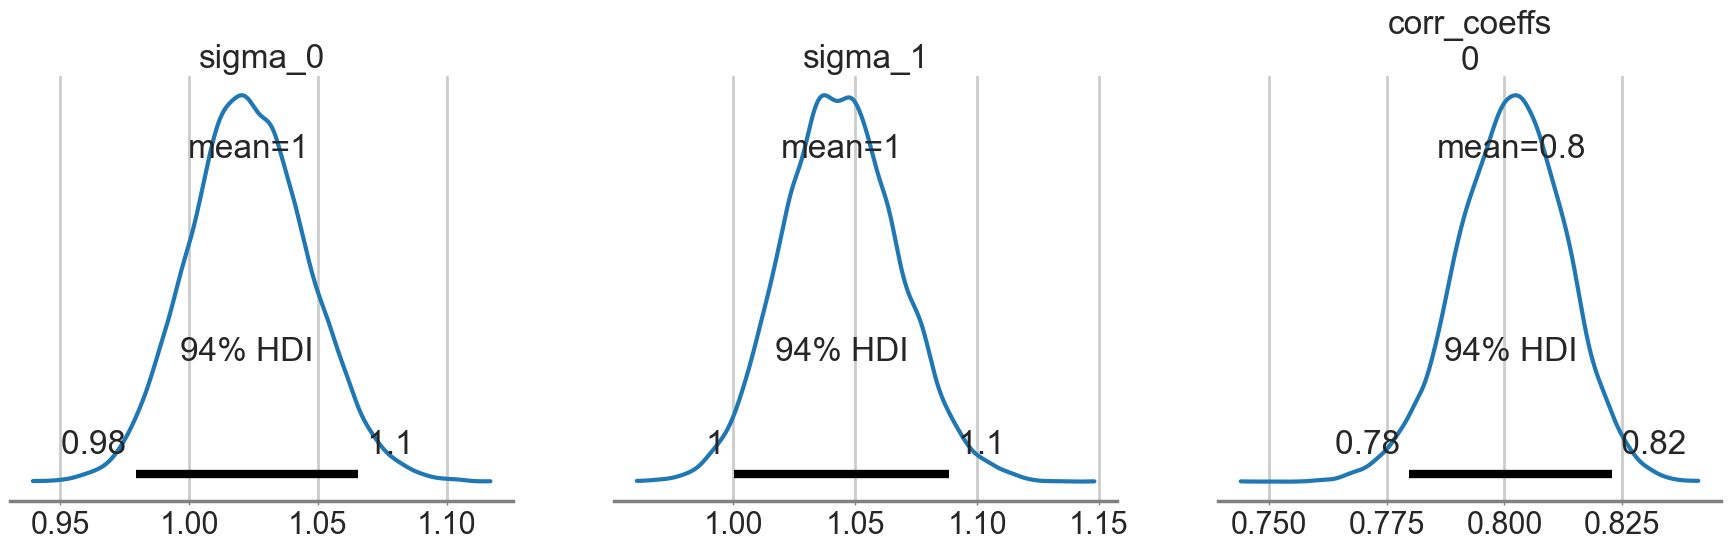

In [18]:
az.plot_posterior(nutstrace2);

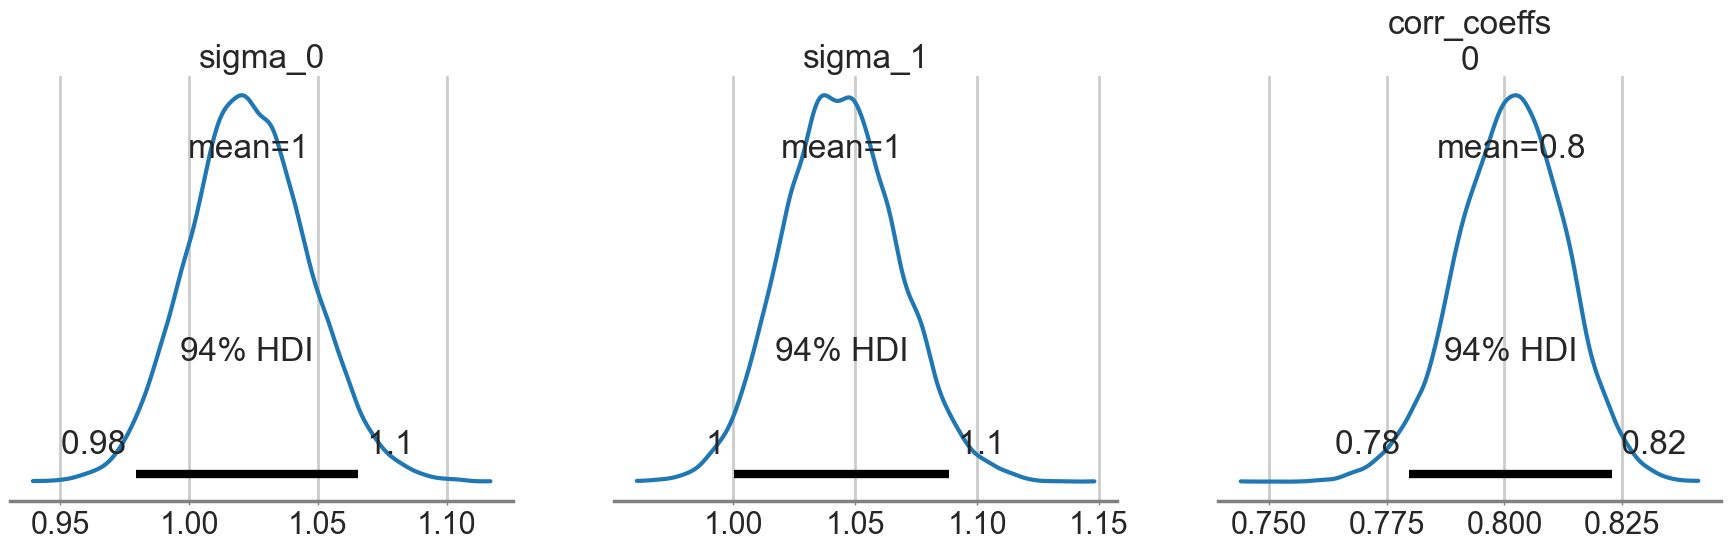

In [19]:
az.plot_posterior(nutstrace2);

## Prior-ing the Cholesky Decomposition

In [20]:
with pm.Model() as modelmvg3:
    ndim = 2
    chol, corr, stds = pm.LKJCholeskyCov('packed_L', n=ndim,
                                 eta=2, sd_dist=pm.Lognormal.dist(0, 1))
    Sigma = pm.Deterministic('Sigma', chol.dot(chol.T))
    mvg = pm.MvNormal('mvg', mu=[0,0], chol=chol, observed=data)

In [21]:
with modelmvg3:
    nutstrace3 = pm.sample(10000, cores=1)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [packed_L]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/pytensor/compile/funct
ion/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)

Sampling 2 chains for 1_000 tune and 10_000 draw iterations (2_000 + 20_000 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [22]:
az.summary(nutstrace3)

/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
packed_L[0],1.024,0.022,0.982,1.066,0.0,0.0,12803.0,14036.0,1.0
packed_L[1],0.838,0.027,0.787,0.888,0.0,0.0,13112.0,13061.0,1.0
packed_L[2],0.624,0.014,0.598,0.650,0.0,0.0,14515.0,13308.0,1.0
"packed_L_corr[0, 0]",1.000,0.000,1.000,1.000,0.0,NaN,20000.0,20000.0,NaN
"packed_L_corr[0, 1]",0.802,0.011,0.780,0.823,0.0,0.0,13610.0,13947.0,1.0
"packed_L_corr[1, 0]",0.802,0.011,0.780,0.823,0.0,0.0,13610.0,13947.0,1.0
"packed_L_corr[1, 1]",1.000,0.000,1.000,1.000,0.0,0.0,18244.0,17084.0,1.0
packed_L_stds[0],1.024,0.022,0.982,1.066,0.0,0.0,12803.0,14036.0,1.0
packed_L_stds[1],1.045,0.023,1.002,1.089,0.0,0.0,13070.0,13749.0,1.0
"Sigma[0, 0]",1.048,0.046,0.964,1.135,0.0,0.0,12803.0,14036.0,1.0


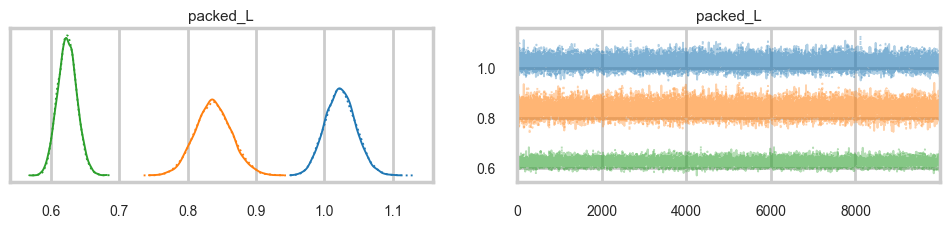

In [23]:
# Filter to free RVs only; deterministic Sigma and corr diagonal
# have constant values that cause KDE overflow in arviz
az.plot_trace(nutstrace3, var_names=["packed_L"]);

Why is this parametrization useful? You will recall from the Gelman schools that we converted a sampler $N(\mu, \sigma) = \mu + \sigma\nu$ where $\nu \sim N(0,1)$. This is the "non-centered" parametrization, and it reduced one layer in the hierarchical model, thus reducing curvature. Helped us produce a different sampler.

The main place we want to model correlations is in **Varying Effects** models, where we hierarchically float both intercept and slope. For example, in our prosocial chimps model we have so far used hiearchcal intercepts for both "actor" and "block", resulting in a cross-correlated model. What if we let there be block and actor specific slopes for both the prosocial-left option and the condition:

![Prosocial chimps model with actor and block varying intercepts and slopes [Source: Statistical Rethinking]](assets/pchimps3.png)

We assume a correlated model for these:

![](assets/pchimps4.png)

If you do this you will get the usual "divergences" warnings from pymc, and will want to use a non-centered parametrization:

![Non-centered parametrization of the varying effects chimps model with z-scores [Source: Statistical Rethinking]](assets/pchimps5.png)

We are assuming 0 mean priors here. This parametrization now makes the priors possibly correlates z-scores. So the next thing we do is to model the correlation, and furthermore, we can do it with the Cholesky Matrix $L$.

Each step will give us faster samplers.